#**Prediction of Store Sales using Regression**

#Problem Statement and Context:

The success of any retail store depends upon its sales. More the sales made, more is the revenue. With a good customer service and care, the customer too enjoys a good shopping experience. This will lead to more in-flow of customers, opening more store branches across a city / country.

To enable this, store owners rely heavily on past data to predict future sales. This will help them in strategizing their business models and come up with innovative techniques and ideas to attract customers and set realistic goals.

Many medium to large stores implement this kind of analytics to understand trends like which products are getting sold faster, what are the slow moving products, impact of store types, etc. With new branches of the store, the analysis can get more complex and may also involve stiff competition from other competitors.

#Business Objective:
  **Build a Model to Predict the Sales of a Store**

#Importing Necessary Libraries:


In [ ]:
# Importing libraries
import warnings

# this will help in making the Python code more structured automatically
#%load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Data Importing:

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DS3_C6_S1_Regression_StoreSales_Data_Project.csv to DS3_C6_S1_Regression_StoreSales_Data_Project.csv


#Data Reading:

In [ ]:
df=pd.read_csv("/content/DS3_C6_S1_Regression_StoreSales_Data_Project.csv")

In [ ]:
df.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                14204 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                14204 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.3+ MB


In [ ]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

#Descriptive Statistics of numerical data

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_Weight,14204.0,12.793380,4.651716,4.555000,8.710000,12.600000,16.750000,21.350000
Item_Visibility,14204.0,0.070301,0.048621,0.003575,0.033143,0.062347,0.094037,0.328391
Item_MRP,14204.0,141.004977,62.086938,31.290000,94.012000,142.247000,185.855600,266.888400
Outlet_Establishment_Year,14204.0,1997.830681,8.371664,1985.000000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290000,834.247400,1794.331000,3101.296400,13086.964800


#Descriptive details of categorical data

In [ ]:
df[['Item_Fat_Content','Item_Type','Outlet_Size','Outlet_Location_Type','Outlet_Type']].describe()

,Item_Fat_Content,Item_Type,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,14204,14204,14204,14204,14204
unique,2,16,3,3,4
top,Low Fat,Fruits and Vegetables,Small,Tier 3,Supermarket Type1
freq,9185,2013,7071,5583,9294


#Number of unique values:

In [ ]:
df.nunique()

,0
Item_Identifier,1559
Item_Weight,415
Item_Fat_Content,2
Item_Visibility,13010
Item_Type,16
Item_MRP,8052
Outlet_Identifier,10
Outlet_Establishment_Year,9
Outlet_Size,3
Outlet_Location_Type,3


#Dup code

In [ ]:
df.duplicated().sum()

np.int64(0)

#missing values:

In [ ]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


#Seperating train and test data

In [ ]:
df1=df[df['Item_Outlet_Sales'].notnull()]

In [ ]:
df1.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


#Exploratory Data Analysis(EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [ ]:
df1.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


#Univariate Analysis

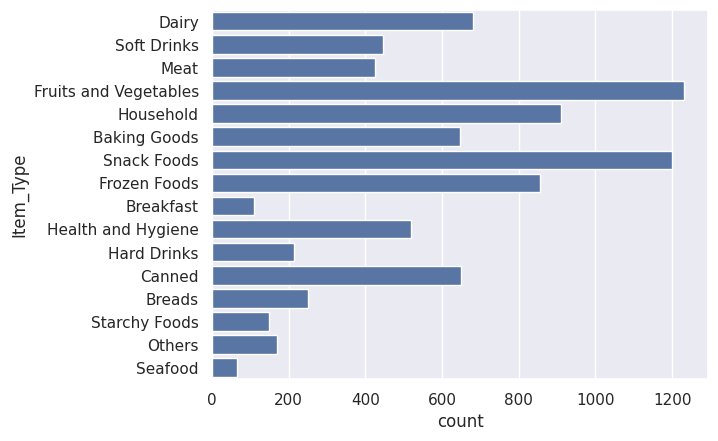

In [ ]:
sns.countplot(y='Item_Type', data=df1)
plt.show()

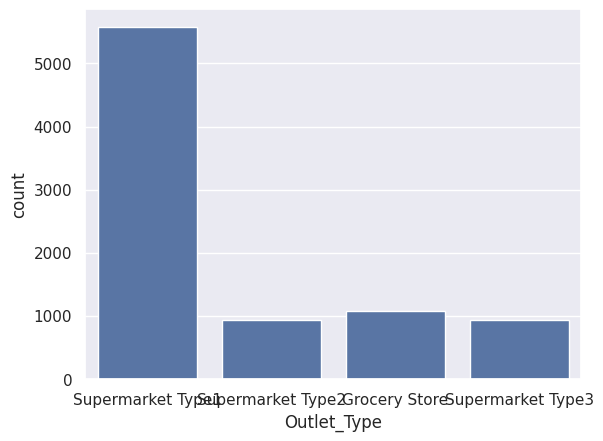

In [ ]:
sns.countplot(x='Outlet_Type', data=df1)
plt.show()

<Axes: >

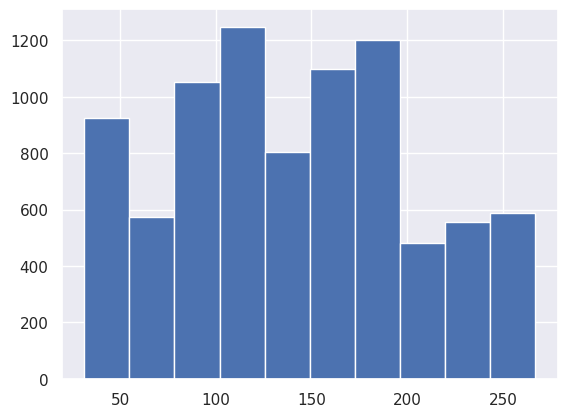

In [ ]:
df1['Item_MRP'].hist()

<Axes: xlabel='Item_Visibility'>

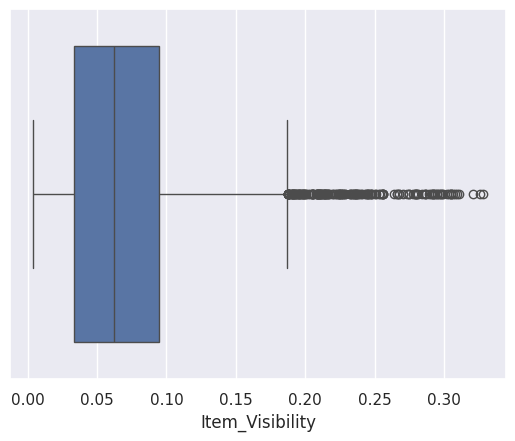

In [ ]:
sns.boxplot(x=df1['Item_Visibility'])

In [ ]:
#Handling Outliers
Q1 = df1['Item_Visibility'].quantile(0.25)
Q3 = df1['Item_Visibility'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df1['Item_Visibility'] = np.where(df1['Item_Visibility'] > upper, upper, df1['Item_Visibility'])
df1['Item_Visibility'] = np.where(df1['Item_Visibility'] < lower, lower, df1['Item_Visibility'])

/tmp/ipykernel_28826/3258614294.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Item_Visibility'] = np.where(df1['Item_Visibility'] > upper, upper, df1['Item_Visibility'])
/tmp/ipykernel_28826/3258614294.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Item_Visibility'] = np.where(df1['Item_Visibility'] < lower, lower, df1['Item_Visibility'])


<Axes: xlabel='Item_Visibility'>

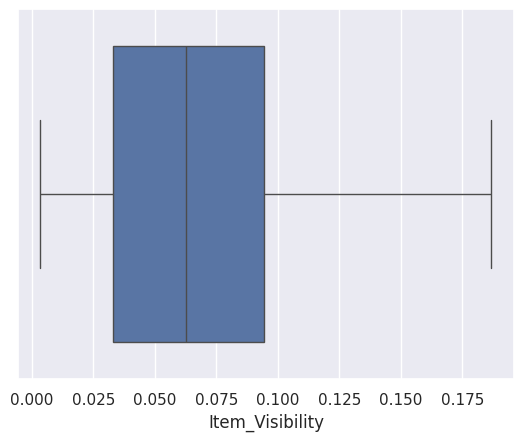

In [ ]:
sns.boxplot(x=df1['Item_Visibility'])

<Axes: xlabel='Item_MRP'>

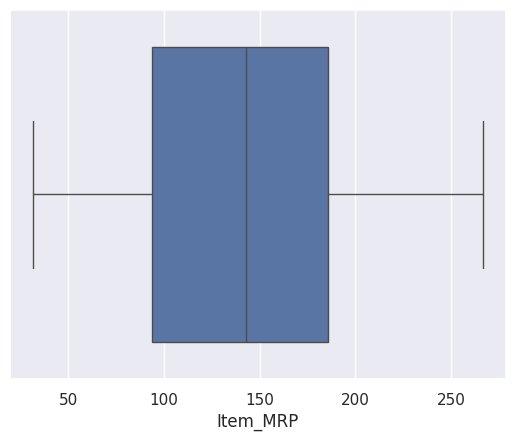

In [ ]:
sns.boxplot(x=df1['Item_MRP'])

<Axes: xlabel='Item_Weight'>

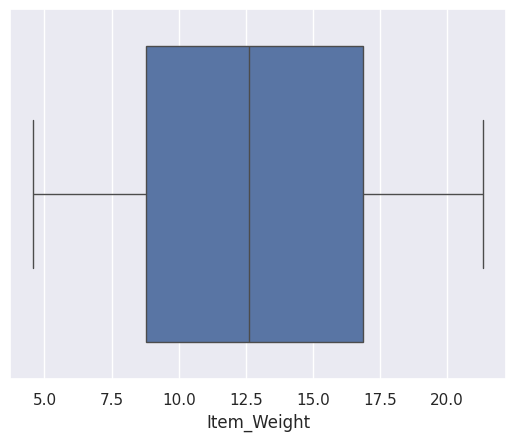

In [ ]:
sns.boxplot(x=df1['Item_Weight'])

#Bivariate Analysis

<Axes: xlabel='Item_MRP', ylabel='Item_Outlet_Sales'>

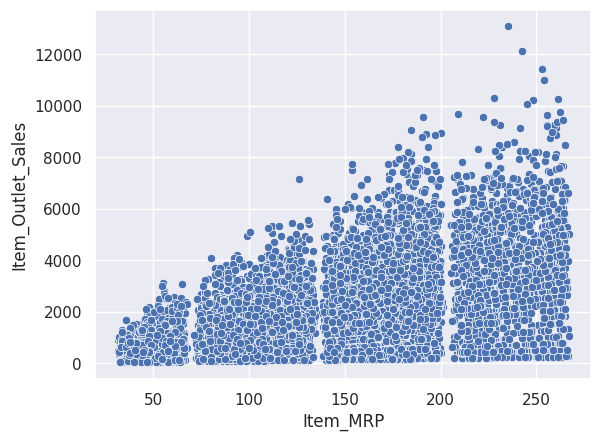

In [ ]:
sns.scatterplot(x='Item_MRP',
                y='Item_Outlet_Sales',
                data=df1)

<Axes: xlabel='Outlet_Type', ylabel='Item_Outlet_Sales'>

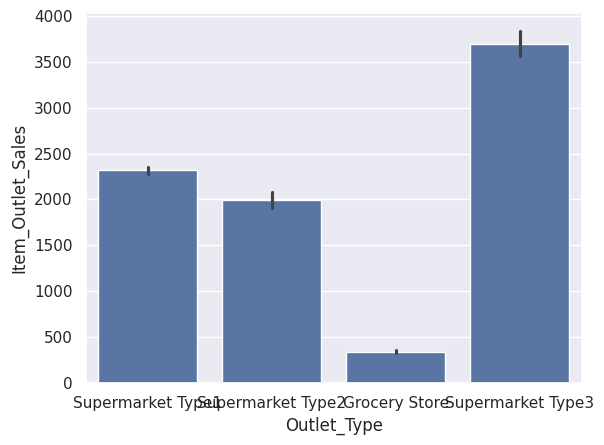

In [ ]:
sns.barplot(x='Outlet_Type',y='Item_Outlet_Sales',
            data=df1)

/tmp/ipykernel_28826/2849470143.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1.Item_Outlet_Sales)


<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

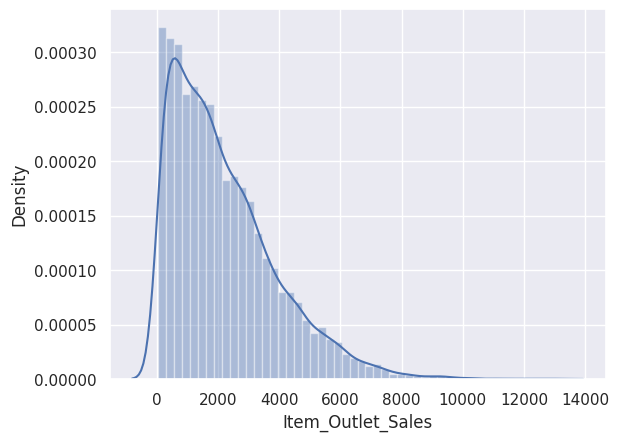

In [ ]:
sns.distplot(df1.Item_Outlet_Sales)

In [ ]:
df1['Item_Outlet_Sales']=np.log1p(df['Item_Outlet_Sales'])

/tmp/ipykernel_28826/449565997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Item_Outlet_Sales']=np.log1p(df['Item_Outlet_Sales'])


/tmp/ipykernel_28826/2849470143.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1.Item_Outlet_Sales)


<Axes: xlabel='Item_Outlet_Sales', ylabel='Density'>

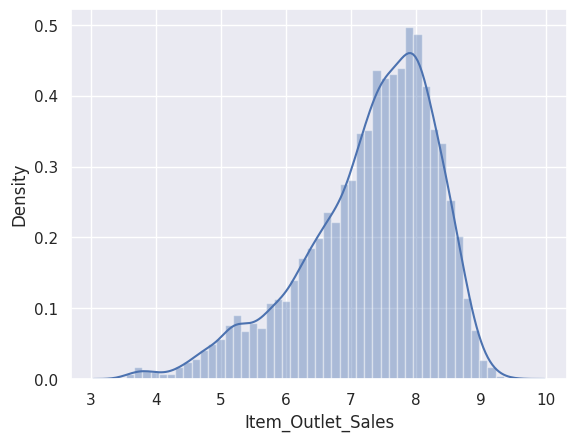

In [ ]:
sns.distplot(df1.Item_Outlet_Sales)

In [ ]:
df1.Item_Outlet_Sales.skew()

np.float64(-0.8822656923242803)

<Axes: xlabel='Outlet_Location_Type', ylabel='Item_Outlet_Sales'>

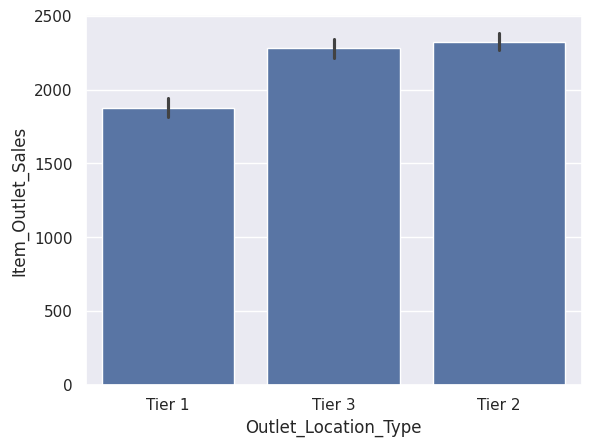

In [ ]:
sns.barplot(x='Outlet_Location_Type',y='Item_Outlet_Sales',
            data=df1)

<Axes: xlabel='Item_Outlet_Sales', ylabel='Outlet_Size'>

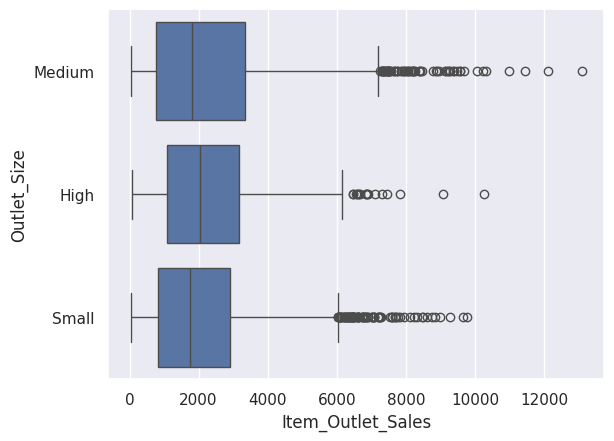

In [ ]:
sns.boxplot(y='Outlet_Size',x='Item_Outlet_Sales',data=df1)

In [ ]:
df1.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700


<Axes: xlabel='Item_Visibility', ylabel='Item_Outlet_Sales'>

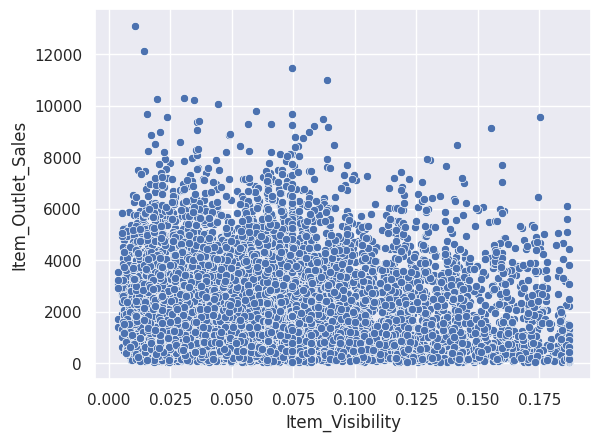

In [ ]:
sns.scatterplot(x='Item_Visibility',y='Item_Outlet_Sales',data=df1)

<Axes: xlabel='Item_Weight', ylabel='Item_Outlet_Sales'>

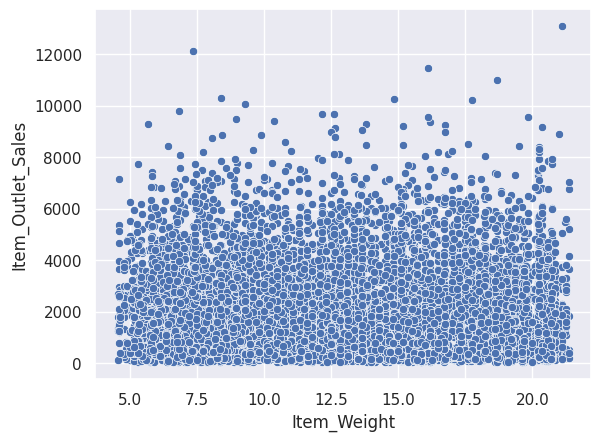

In [ ]:
sns.scatterplot(x='Item_Weight',y='Item_Outlet_Sales',data=df1)

#Multivariate Analysis

In [ ]:
df1.head(2)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228


In [ ]:
# Separating Numerical Variables
numeric_columns = df1.select_dtypes(include=np.number).columns.tolist()

In [ ]:
df1[numeric_columns].corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.018381,0.026172,-0.012823,0.013261
Item_Visibility,-0.018381,1.000000,-0.006024,-0.067476,-0.121788
Item_MRP,0.026172,-0.006024,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.012823,-0.067476,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.013261,-0.121788,0.567574,-0.049135,1.000000


<Axes: >

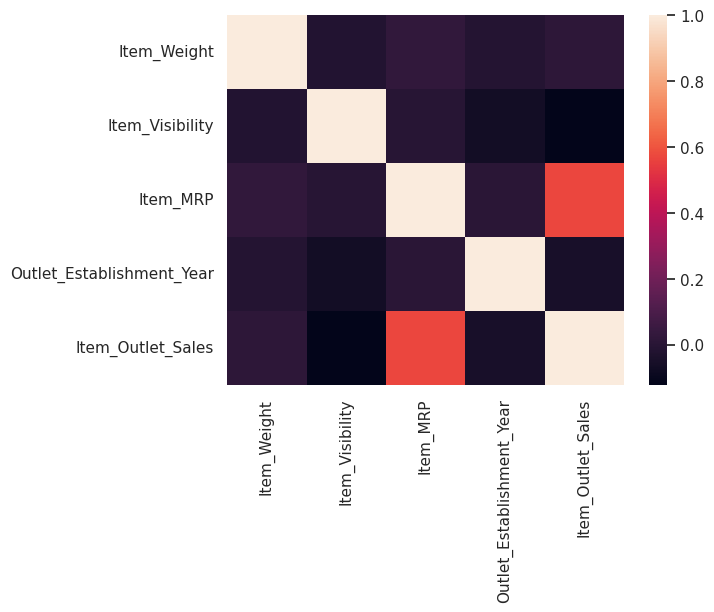

In [ ]:
sns.heatmap(df1[numeric_columns].corr())

In [ ]:
# brand_name
df2 = df1.drop(["Item_Identifier","Outlet_Identifier","Outlet_Establishment_Year",'Item_Fat_Content'], axis = 1)

# Making all categorical data as dummy variable

df2 = pd.get_dummies(df2,
      columns=df2.select_dtypes(include=["object", "category"]).columns.tolist(),
    drop_first=True,
)
df2.head()

,Item_Weight,Item_Visibility,Item_MRP,Item_Outlet_Sales,Item_Type_Breads,Item_Type_Breakfast,Item_Type_Canned,Item_Type_Dairy,Item_Type_Frozen Foods,Item_Type_Fruits and Vegetables,...,Item_Type_Snack Foods,Item_Type_Soft Drinks,Item_Type_Starchy Foods,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,8.225808,False,False,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,6.096776,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
2,17.50,0.016760,141.6180,7.648868,False,False,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
3,19.20,0.074402,182.0950,6.597664,False,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
4,8.93,0.064299,53.8614,6.903451,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False


# Building a Linear Regression model

We will split the data into training data and testing data. Where training data have 70% observations and 30% testing observatins. We will build a Linear Regression model using the training data and then check it's performance on test data.

In [ ]:
# Seprating target variables from data

feature_columns = df2.columns.difference( ['Item_Outlet_Sales'])
feature_columns

Index(['Item_MRP', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods', 'Item_Visibility',
       'Item_Weight', 'Outlet_Location_Type_Tier 2',
       'Outlet_Location_Type_Tier 3', 'Outlet_Size_Medium',
       'Outlet_Size_Small', 'Outlet_Type_Supermarket Type1',
       'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3'],
      dtype='object')

In [ ]:
# Spliting data into training and testing - 70% data as training set and 30% as testing set

x_train, x_test, y_train, y_test = train_test_split(df2[feature_columns],
                                                  df1['Item_Outlet_Sales'],
                                                  test_size = 0.3,
                                                  random_state =24)


print("Observations in train data =", x_train.shape[0])
print("Observations in test data =", x_test.shape[0])

Observations in train data = 5966
Observations in test data = 2557


## Model building on training data

We will train and fit the model on the 70% of training data using linear regression model from sklearn.

In [ ]:
## Building the model with train set.
from sklearn.linear_model import LinearRegression

# regression model
linreg = LinearRegression()
linreg.fit(x_train, y_train)

LinearRegression()

## Prediction on test data

We will do predictions on the test set with the model, and compare the actual output values with the predicted values.

In [ ]:
# prediction on test data x_test
y_pred = linreg.predict(x_test)

In [ ]:
# Creating datframe of actule values and predicted values
df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
df_pred_test.head()

,Actual,Predicted
6750,8.037749,8.124808
6045,8.082748,7.213473
435,8.019518,8.112046
4111,6.674524,6.446377
2690,6.976914,6.706988


In [ ]:
# R2
r2_score(y_test, y_pred)

0.7049233782837505

In [ ]:
# MSE
mse = mean_squared_error(y_test, y_pred)
print(mse)

0.30254475160808564


In [ ]:
train_score = linreg.score(x_train, y_train)
test_score = linreg.score(x_test, y_test)

print("Train:", train_score)
print("Test:", test_score)

Train: 0.7269644237791594
Test: 0.7049233782837505


In [ ]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [ ]:
# checking model performance on train set (seen 70% data)
print("Model Performance on training data\n")
linreg_train_perf = model_performance_regression(linreg, x_train, y_train)

linreg_train_perf

Model Performance on training data



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.531016,0.412676,0.726964,0.725815,5.986763


In [ ]:
import statsmodels.api as sm

# Add the constant to x_train and x_test
x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)

# Convert True/False and other objects to floats/ints
# This fixes the "dtype of object" error
x_train = x_train.astype(float)
x_test = x_test.astype(float)

# Fit the model (Target y_train, then Features x_train)
olsmodel = sm.OLS(y_train, x_train).fit()

#Display the summary
print(olsmodel.summary())

                            OLS Regression Results                            
Dep. Variable:      Item_Outlet_Sales   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     632.6
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        12:08:49   Log-Likelihood:                -4689.1
No. Observations:                5966   AIC:                             9430.
Df Residuals:                    5940   BIC:                             9604.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:
df3=df[df['Item_Outlet_Sales'].isnull()]